In [1]:
!pip install mediapipe opencv-python pandas numpy scikit-learn joblib
!pip uninstall -y jax mediapipe
!pip install jax mediapipe

Found existing installation: jax 0.8.0
Uninstalling jax-0.8.0:
  Successfully uninstalled jax-0.8.0
Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached jax-0.8.0-py3-none-any.whl.metadata (13 kB)
  Using cached mediapipe-0.10.21-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
  Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.18-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.15-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached jax-0.8.0-py3-none-any.whl (2.9 MB)
Using cached m

In [91]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import os
from tqdm import tqdm


In [92]:
import zipfile
import os

with zipfile.ZipFile("/dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

os.listdir("dataset")


['dataset']

In [93]:
DATASET_PATH = "/content/dataset/dataset"


In [94]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [95]:
def extract_frame_landmarks(video_path, label):
    cap = cv2.VideoCapture(video_path)
    frame_data = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        if results.multi_hand_landmarks:
            lm_list = []
            for lm in results.multi_hand_landmarks[0].landmark:
                lm_list.extend([lm.x, lm.y, lm.z])
        else:
            lm_list = [np.nan]*63  # 21 landmarks × 3

        lm_list.append(label)
        frame_data.append(lm_list)

    cap.release()
    return frame_data

In [96]:
all_rows = []
for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue

    print(f"Processing: {label}")
    for video in tqdm(os.listdir(class_path)):
        video_path = os.path.join(class_path, video)
        all_rows.extend(extract_frame_landmarks(video_path, label))

Processing: up


  0%|          | 0/14 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 14/14 [00:17<00:00,  1.23s/it]


Processing: like


100%|██████████| 16/16 [00:35<00:00,  2.22s/it]


Processing: stop


100%|██████████| 16/16 [00:23<00:00,  1.45s/it]


Processing: ok


100%|██████████| 15/15 [00:22<00:00,  1.47s/it]


In [100]:
columns = []
for i in range(21):
    columns += [f"x_{i}", f"y_{i}", f"z_{i}"]
columns.append("label")

df = pd.DataFrame(all_rows, columns=columns)
df.to_csv("/content/hand_sign_frame_dataset.csv", index=False)

print("Dataset created: /content/hand_sign_frame_dataset.csv")

Dataset created: /content/hand_sign_frame_dataset.csv


In [101]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
!pip install xgboost
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
csv_path = "/content/hand_sign_frame_dataset.csv"
df = pd.read_csv(csv_path)


In [104]:
print("Dataset Loaded")
print("Shape:", df.shape)
print(df.label.value_counts())

Dataset Loaded
Shape: (2998, 64)
label
like    1025
stop     763
ok       688
up       522
Name: count, dtype: int64


In [105]:
df = df.fillna(0)


In [106]:
X = df.drop("label", axis=1)
y = df["label"]


In [107]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [108]:
scaler = StandardScaler()
if not X.empty:
    X_scaled = scaler.fit_transform(X)
else:
    print("No data available for scaling. X is empty.")

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [110]:
from xgboost import XGBClassifier


In [111]:
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss"
)

In [112]:
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [113]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)


In [114]:
print(f"\nAccuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 99.33%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       205
           1       0.99      1.00      1.00       138
           2       1.00      0.98      0.99       153
           3       1.00      0.99      1.00       104

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



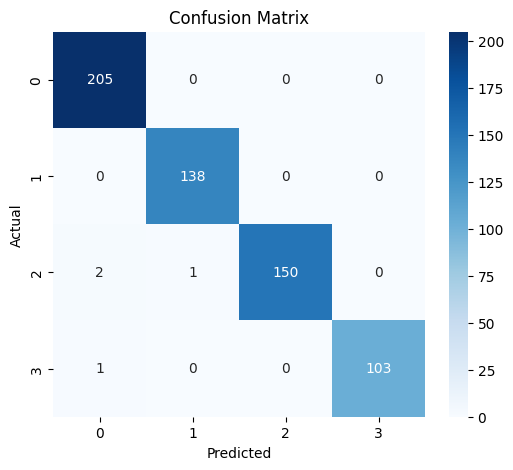

In [115]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [116]:
joblib.dump(model, "/content/hand_sign_model.pkl")
joblib.dump(scaler, "/content/scaler.pkl")
joblib.dump(label_encoder, "/content/label_encoder.pkl")

print("\n Model, Scaler & Label Encoder Saved Successfully!")
print("Model: /content/hand_sign_model.pkl")
print("Scaler: /content/scaler.pkl")
print("Label Encoder: /content/label_encoder.pkl")


 Model, Scaler & Label Encoder Saved Successfully!
Model: /content/hand_sign_model.pkl
Scaler: /content/scaler.pkl
Label Encoder: /content/label_encoder.pkl
